# $^{171}$Yb shelving 后有效两能级 Rydberg CZ 的 phase-only GRAPE 时间扫描

本 notebook 是新的 workflow 第一阶段产物：只做 notebook 原型和验证，等待审查后才允许进入 Slides 阶段。

目标按照用户修正后的物理路线：不展开 Ma 2023 的多个 Rydberg 子能级，而是参考 Muniz et al., PRX Quantum **6**, 020334 (2025), DOI `10.1103/PRXQuantum.6.020334` 中的 $^{171}\mathrm{Yb}$ ground-state nuclear-spin qubit + clock shelving + UV Rydberg entangling gate 图像。我们假设前后 shelving/unshelving 已经理想完成，只优化 shelving 后的 UV entangling segment，在有效 `|c> <-> |r>` 两能级系统中寻找高 fidelity CZ 的最短实现时间。

本 notebook 仍保留开放系统因素的最小版本：只考虑 Rydberg 态寿命 $T_{1,r}=65\ \mu\mathrm{s}$ 对应的 one-way decay。其他噪声、多个 $m_F$ Rydberg 子能级、Doppler、laser phase noise、UV 振幅漂移、clock shelving 误差都暂不加入。


## 物理模型：shelving 后的 reduced UV 段

逻辑门完整过程为：

1. `|1>` 通过 clock pulse 被 shelving 到 metastable `|c>`；
2. UV pulse 驱动 `|c> <-> |r>`，利用 Rydberg blockade 积累 CZ 相位；
3. unshelving 将 `|c>` 映回逻辑 `|1>`。

本 notebook 只研究第 2 步 UV segment，假设 shelving/unshelving 理想，因此计算分支为：

- `|00>`：UV 段中不参与演化，只积累平凡相位；
- `|01>` 与 `|10>`：shelving 后等价为单原子分支 `|c> <-> |r>`；
- `|11>`：shelving 后为双原子分支 `|cc> <-> |W_cr> <-> |rr>`，其中
  $|W_{cr}\rangle=(|cr\rangle+|rc\rangle)/\sqrt2$，`|rr>` 受到 blockade shift $V$。

为了直接评估 CZ，本 notebook 使用 reduced basis：

```text
0 |00>
1 |01_c>     representative for |01> and |10> after shelving
2 |01_r>
3 |11_cc>
4 |11_Wcr>
5 |11_rr>
6 |loss>
```

计算态 representative indices 为 `(0, 1, 3)`，权重为 `(1, 2, 1)`。其中 `|01_c>` 同时代表 `|01>` 与 `|10>` 两条等价分支。


## Hamiltonian、控制和单位

内部采用无量纲化，令最大 UV Rabi 频率为单位：

$$
\Omega_{\max}/2\pi = 10\ \mathrm{MHz},\qquad \tau=\Omega_{\max}t.
$$

控制写成固定振幅 envelope 加相位：

$$
H(t)=H_d+A(t)\cos\phi(t)H_x+A(t)\sin\phi(t)H_y.
$$

其中 $A(t)$ 是 Gaussian-edge envelope，边沿之外 plateau 恒为 1，即物理 Rabi 频率恒为 $10\ \mathrm{MHz}$；优化变量只有 slot-wise phase $\phi_k$，以及用于对齐目标门的 global / single-qubit phase 参数 `theta0`, `theta1`。

耦合矩阵元采用标准 Rydberg blockade 对称子空间：

- 单原子分支：`|01_c> <-> |01_r>` 的 quadrature coupling 为 $1/2$；
- 双原子分支：`|11_cc> <-> |11_Wcr>` 和 `|11_Wcr> <-> |11_rr>` 的 coupling 为 $1/\sqrt2$；
- `|11_rr>` 的 drift 为 blockade $V/\Omega_{\max}$。

默认标定使用当前项目 v5/PRX Quantum 6, 020334 语境中的量级：

- UV Rabi max：$10\ \mathrm{MHz}$；
- blockade shift：$160\ \mathrm{MHz}$，即 $V/\Omega_{\max}=16$；
- Rydberg lifetime：$65\ \mu\mathrm{s}$，即 $\gamma_r=1/(\Omega_{\max}T_{1,r})$。


## 开放系统目标和时间扫描

由于唯一噪声是从 Rydberg 态流向 `|loss>` 的 one-way decay，计算子空间的相干块可由 no-jump 非厄米 generator 精确描述：

$$
G(t)=-iH(t)-\frac12\sum_j C_j^\dagger C_j.
$$

本 notebook 用这个 7 维 generator 做 phase-only GRAPE，并用有限差分检查 phase / target-phase 梯度。对每个候选 UV 时间，优化后计算

$$
F=\frac{4F_\mathrm{pro}+P_\mathrm{active}}{5},
$$

其中 $F_\mathrm{pro}$ 是带 `(1,2,1)` 权重的 reduced process overlap，$P_\mathrm{active}$ 是计算分支回到各自代表态的 weighted survival。二者不是同一个量：

- `process_fidelity` / $F_\mathrm{pro}$：检查 active 计算分支上的相干 CZ 相位 overlap，定义为
  $$
  F_\mathrm{pro}=\frac{\left|\sum_i w_i u_i^* z_i\right|^2}{16},
  $$
  其中 $z_i=\langle i|\psi_i(T)\rangle$，$u_i$ 是目标 CZ 加可补偿 global / single-qubit phase 后的目标相位。
- `active_population` / $P_\mathrm{active}$：只检查人口是否还留在对应 active representative 态，定义为
  $$
  P_\mathrm{active}=\frac{\sum_i w_i |z_i|^2}{4}.
  $$
  它是 survival / leakage 诊断，不等同于 process fidelity。
- notebook 中报告的 `fidelity` 是组合 gate-fidelity proxy：
  $$
  F=\frac{4F_\mathrm{pro}+P_\mathrm{active}}{5}.
  $$

因此本 notebook 没有把 `active channel` 简单称为 process fidelity；`process_fidelity` 和 `active_population` 分开报告，最终用上式组合。扫描目标是找出满足阈值的最短 UV segment time。本 notebook 默认用较小扫描作为开发 demo；更密的扫描应在审查通过后进入下一阶段或实验脚本。


In [1]:
from __future__ import annotations

import json
import math
import os
import sys
import time
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm, expm_frechet
from scipy.optimize import minimize

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path.cwd().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from neutral_yb.models.ma2023_pulse import gaussian_edge_envelope, phase_regularization, wrap_phase


In [2]:
@dataclass(frozen=True)
class EffectiveShelvedCZConfig:
    num_tslots: int
    uv_time_ns: float
    uv_rabi_hz: float = 10.0e6
    blockade_shift_hz: float = 160.0e6
    rydberg_lifetime_s: float = 65.0e-6
    edge_fraction: float = 0.20
    sigma_fraction: float = 0.08
    phase_smoothness_weight: float = 2e-4
    phase_curvature_weight: float = 2e-4
    max_iter: int = 120
    seed: int = 7

    @property
    def omega_rad_s(self) -> float:
        return 2.0 * math.pi * self.uv_rabi_hz

    @property
    def evo_time(self) -> float:
        return self.omega_rad_s * self.uv_time_ns * 1e-9

    @property
    def dt(self) -> float:
        return self.evo_time / self.num_tslots

    @property
    def blockade_over_omega(self) -> float:
        return self.blockade_shift_hz / self.uv_rabi_hz

    @property
    def rydberg_decay_rate(self) -> float:
        return 1.0 / (self.omega_rad_s * self.rydberg_lifetime_s)


@dataclass(frozen=True)
class EffectiveShelvedCZResult:
    uv_time_ns: float
    fidelity: float
    process_fidelity: float
    active_population: float
    leakage: float
    rydberg_decay_estimate: float
    objective: float
    success: bool
    num_iter: int
    num_calls: int
    wall_time_s: float
    theta0: float
    theta1: float
    phases: np.ndarray
    envelope: np.ndarray
    ctrl_x: np.ndarray
    ctrl_y: np.ndarray
    gradient_checks: list[dict[str, float]]


In [3]:
class EffectiveShelvedCZGRAPE:
    basis_labels = ("00", "01_c", "01_r", "11_cc", "11_Wcr", "11_rr", "loss")
    computational_indices = (0, 1, 3)
    weights = np.array([1.0, 2.0, 1.0], dtype=np.float64)

    def __init__(self, config: EffectiveShelvedCZConfig) -> None:
        self.config = config
        self.dimension = 7
        self.h_d = np.zeros((self.dimension, self.dimension), dtype=np.complex128)
        self.h_d[5, 5] = config.blockade_over_omega
        self.h_x = np.zeros_like(self.h_d)
        self.h_y = np.zeros_like(self.h_d)
        self._add_quadrature_coupling(1, 2, 0.5)
        self._add_quadrature_coupling(3, 4, 1.0 / np.sqrt(2.0))
        self._add_quadrature_coupling(4, 5, 1.0 / np.sqrt(2.0))
        self.decay_matrix = self._build_decay_matrix()
        self.g_d = -1j * self.h_d - 0.5 * self.decay_matrix
        self.g_x = -1j * self.h_x
        self.g_y = -1j * self.h_y
        self.envelope = gaussian_edge_envelope(
            config.num_tslots,
            config.edge_fraction,
            config.sigma_fraction,
        )

    def initial_guess(self) -> np.ndarray:
        x = np.linspace(-1.0, 1.0, self.config.num_tslots, dtype=np.float64)
        # A symmetric chirped seed is more useful than a flat phase for short-time blockade gates.
        phases = 1.25 * x - 1.10 * x**3
        return np.concatenate([wrap_phase(phases), np.array([0.0, 0.0], dtype=np.float64)])

    def optimize(self, initial_variables: np.ndarray | None = None) -> EffectiveShelvedCZResult:
        variables0 = self.initial_guess() if initial_variables is None else np.asarray(initial_variables, dtype=np.float64)
        started = time.perf_counter()
        result = minimize(
            fun=self.objective_and_gradient,
            x0=variables0,
            jac=True,
            method="L-BFGS-B",
            bounds=[(-np.pi, np.pi)] * self.config.num_tslots + [(-2.0 * np.pi, 2.0 * np.pi), (-2.0 * np.pi, 2.0 * np.pi)],
            options={"maxiter": int(self.config.max_iter), "ftol": 1e-10, "maxls": 30},
        )
        wall_time = time.perf_counter() - started
        return self.result_from_variables(
            result.x,
            objective=float(result.fun),
            success=bool(result.success),
            num_iter=int(result.nit),
            num_calls=int(result.nfev),
            wall_time_s=wall_time,
        )

    def objective_and_gradient(self, variables: np.ndarray) -> tuple[float, np.ndarray]:
        phases = wrap_phase(variables[:-2])
        theta0 = float(variables[-2])
        theta1 = float(variables[-1])
        ctrl_x, ctrl_y = self.controls_from_phases(phases)
        fidelity, _fpro, _active, _leakage, grad_x, grad_y, theta0_grad, theta1_grad = self.fidelity_and_gradients(
            ctrl_x,
            ctrl_y,
            theta0,
            theta1,
        )
        reg_cost, reg_grad = phase_regularization(
            phases,
            self.config.phase_smoothness_weight,
            self.config.phase_curvature_weight,
        )
        fidelity_phase_grad = -grad_x * self.envelope * np.sin(phases) + grad_y * self.envelope * np.cos(phases)
        objective = 1.0 - fidelity + reg_cost
        gradient = np.concatenate([
            -fidelity_phase_grad + reg_grad,
            np.array([-theta0_grad, -theta1_grad], dtype=np.float64),
        ])
        return float(objective), gradient

    def result_from_variables(
        self,
        variables: np.ndarray,
        *,
        objective: float,
        success: bool,
        num_iter: int,
        num_calls: int,
        wall_time_s: float,
    ) -> EffectiveShelvedCZResult:
        phases = wrap_phase(variables[:-2])
        theta0 = float(variables[-2])
        theta1 = float(variables[-1])
        ctrl_x, ctrl_y = self.controls_from_phases(phases)
        fidelity, process_fidelity, active_population, leakage, *_ = self.fidelity_and_gradients(ctrl_x, ctrl_y, theta0, theta1)
        return EffectiveShelvedCZResult(
            uv_time_ns=float(self.config.uv_time_ns),
            fidelity=float(fidelity),
            process_fidelity=float(process_fidelity),
            active_population=float(active_population),
            leakage=float(leakage),
            rydberg_decay_estimate=float(self.rydberg_decay_population(ctrl_x, ctrl_y)),
            objective=float(objective),
            success=success,
            num_iter=num_iter,
            num_calls=num_calls,
            wall_time_s=wall_time_s,
            theta0=theta0,
            theta1=theta1,
            phases=phases,
            envelope=self.envelope.copy(),
            ctrl_x=ctrl_x,
            ctrl_y=ctrl_y,
            gradient_checks=[],
        )

    def controls_from_phases(self, phases: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        bounded = wrap_phase(phases)
        return self.envelope * np.cos(bounded), self.envelope * np.sin(bounded)

    def fidelity_and_gradients(self, ctrl_x: np.ndarray, ctrl_y: np.ndarray, theta0: float, theta1: float):
        slots = int(ctrl_x.size)
        slice_propags = [expm(self.config.dt * self.generator(float(x), float(y))) for x, y in zip(ctrl_x, ctrl_y)]
        final_states = []
        prefixes_by_state = []
        for basis_index in self.computational_indices:
            state = np.zeros(self.dimension, dtype=np.complex128)
            state[basis_index] = 1.0
            prefixes = [state]
            for propagator in slice_propags:
                state = propagator @ state
                prefixes.append(state)
            final_states.append(state)
            prefixes_by_state.append(prefixes)

        z = np.array(
            [final_states[index][basis_index] for index, basis_index in enumerate(self.computational_indices)],
            dtype=np.complex128,
        )
        signs = np.array([1.0, 1.0, -1.0], dtype=np.complex128)
        target_conj = np.array([
            np.exp(-1j * theta0),
            np.exp(-1j * (theta0 + theta1)),
            np.exp(-1j * (theta0 + 2.0 * theta1)),
        ])
        trace = np.sum(self.weights * signs * target_conj * z)
        process_fidelity = float(abs(trace) ** 2 / 16.0)
        active_population = float(np.sum(self.weights * np.abs(z) ** 2) / 4.0)
        leakage = float(1.0 - active_population)
        fidelity = float((4.0 * process_fidelity + active_population) / 5.0)

        suffix_propags = [np.eye(self.dimension, dtype=np.complex128) for _ in range(slots)]
        suffix = np.eye(self.dimension, dtype=np.complex128)
        for slot in range(slots - 1, -1, -1):
            suffix_propags[slot] = suffix
            suffix = suffix @ slice_propags[slot]

        grad_x = np.zeros(slots, dtype=np.float64)
        grad_y = np.zeros(slots, dtype=np.float64)
        for slot, (x_value, y_value) in enumerate(zip(ctrl_x, ctrl_y)):
            generator = self.generator(float(x_value), float(y_value))
            du_x = expm_frechet(self.config.dt * generator, self.config.dt * self.g_x, compute_expm=False)
            du_y = expm_frechet(self.config.dt * generator, self.config.dt * self.g_y, compute_expm=False)
            for state_index, basis_index in enumerate(self.computational_indices):
                prefix = prefixes_by_state[state_index][slot]
                dz_x = (suffix_propags[slot] @ du_x @ prefix)[basis_index]
                dz_y = (suffix_propags[slot] @ du_y @ prefix)[basis_index]
                grad_x[slot] += self._fidelity_z_gradient(dz_x, z, trace, target_conj, signs, state_index)
                grad_y[slot] += self._fidelity_z_gradient(dz_y, z, trace, target_conj, signs, state_index)

        dtrace_theta0 = -1j * trace
        dtrace_theta1 = -2j * target_conj[1] * z[1] + 2j * target_conj[2] * z[2]
        theta0_grad = float((4.0 / 5.0) * np.real(np.conj(trace) * dtrace_theta0) / 8.0)
        theta1_grad = float((4.0 / 5.0) * np.real(np.conj(trace) * dtrace_theta1) / 8.0)
        return fidelity, process_fidelity, active_population, leakage, grad_x, grad_y, theta0_grad, theta1_grad

    def _fidelity_z_gradient(self, dz: complex, z: np.ndarray, trace: complex, target_conj: np.ndarray, signs: np.ndarray, state_index: int) -> float:
        dtrace = self.weights[state_index] * signs[state_index] * target_conj[state_index] * dz
        d_fpro = np.real(np.conj(trace) * dtrace) / 8.0
        d_population = 2.0 * self.weights[state_index] * np.real(np.conj(z[state_index]) * dz) / 4.0
        return float((4.0 * d_fpro + d_population) / 5.0)

    def gradient_check(self, variables: np.ndarray, indices: tuple[int, ...] = (1, -1), epsilon: float = 1e-6) -> list[dict[str, float]]:
        objective, gradient = self.objective_and_gradient(variables)
        checks = []
        for raw_index in indices:
            index = raw_index if raw_index >= 0 else variables.size + raw_index
            plus = variables.copy()
            minus = variables.copy()
            plus[index] += epsilon
            minus[index] -= epsilon
            objective_plus, _ = self.objective_and_gradient(plus)
            objective_minus, _ = self.objective_and_gradient(minus)
            finite_difference = (objective_plus - objective_minus) / (2.0 * epsilon)
            checks.append({
                "index": float(index),
                "analytic": float(gradient[index]),
                "finite_difference": float(finite_difference),
                "abs_error": float(abs(gradient[index] - finite_difference)),
            })
        return checks

    def rydberg_decay_population(self, ctrl_x: np.ndarray, ctrl_y: np.ndarray) -> float:
        rydberg_indices = (2, 4, 5)
        total = 0.0
        for state_index, basis_index in enumerate(self.computational_indices):
            state = np.zeros(self.dimension, dtype=np.complex128)
            state[basis_index] = 1.0
            decay_probability = 0.0
            for x_value, y_value in zip(ctrl_x, ctrl_y):
                before = float(np.sum(np.abs(state[list(rydberg_indices)]) ** 2))
                state = expm(self.config.dt * self.generator(float(x_value), float(y_value))) @ state
                after = float(np.sum(np.abs(state[list(rydberg_indices)]) ** 2))
                decay_probability += self.config.rydberg_decay_rate * self.config.dt * 0.5 * (before + after)
            total += self.weights[state_index] * decay_probability
        return float(total / 4.0)

    def generator(self, ctrl_x: float, ctrl_y: float) -> np.ndarray:
        return self.g_d + ctrl_x * self.g_x + ctrl_y * self.g_y

    def _build_decay_matrix(self) -> np.ndarray:
        decay = np.zeros((self.dimension, self.dimension), dtype=np.complex128)
        gamma = self.config.rydberg_decay_rate
        for index in (2, 4):
            decay[index, index] += gamma
        decay[5, 5] += 2.0 * gamma
        return decay

    def _add_quadrature_coupling(self, left: int, right: int, strength: float) -> None:
        self.h_x[left, right] = strength
        self.h_x[right, left] = strength
        self.h_y[left, right] = -1j * strength
        self.h_y[right, left] = 1j * strength


In [4]:
# A small deterministic time scan. This is intentionally notebook-scale, not a production fine scan.
UV_TIMES_NS = [60.0, 80.0, 100.0, 125.0, 150.0, 180.0, 220.0, 260.0, 300.0]
NUM_TSLOTS = 48
FIDELITY_TARGET = 0.999

def random_phase_variables(grape: EffectiveShelvedCZGRAPE, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    phases = rng.uniform(-np.pi, np.pi, size=grape.config.num_tslots)
    return np.concatenate([phases, np.array([0.0, 0.0], dtype=np.float64)])

scan_results: list[EffectiveShelvedCZResult] = []
previous_variables: np.ndarray | None = None
started_scan = time.perf_counter()
for time_index, uv_time_ns in enumerate(UV_TIMES_NS):
    cfg = EffectiveShelvedCZConfig(num_tslots=NUM_TSLOTS, uv_time_ns=uv_time_ns)
    grape = EffectiveShelvedCZGRAPE(cfg)
    starts = [grape.initial_guess()]
    if previous_variables is not None:
        starts.append(previous_variables.copy())
    starts.extend(random_phase_variables(grape, seed=1000 + 17 * time_index + restart) for restart in range(3))

    candidates = [grape.optimize(start) for start in starts]
    result = max(candidates, key=lambda item: item.fidelity)
    result = EffectiveShelvedCZResult(**{**result.__dict__, "gradient_checks": grape.gradient_check(np.concatenate([result.phases, [result.theta0, result.theta1]]), indices=(NUM_TSLOTS // 2, -1))})
    previous_variables = np.concatenate([result.phases, np.array([result.theta0, result.theta1])])
    scan_results.append(result)
    print(
        f"T={uv_time_ns:6.1f} ns  F={result.fidelity:.9f}  "
        f"Fpro={result.process_fidelity:.9f}  active={result.active_population:.9f}  "
        f"decay~{result.rydberg_decay_estimate:.3e}  iter={result.num_iter:3d}  "
        f"best_of={len(starts)}"
    )
print("scan wall time", time.perf_counter() - started_scan)


T=  60.0 ns  F=0.609820902  Fpro=0.513092239  active=0.996735556  decay~6.522e-05  iter=120  best_of=4
T=  80.0 ns  F=0.670310313  Fpro=0.600435602  active=0.949809156  decay~2.236e-04  iter= 55  best_of=5
T= 100.0 ns  F=0.774223784  Fpro=0.747721926  active=0.880231219  decay~4.433e-04  iter= 47  best_of=5
T= 125.0 ns  F=0.901940171  Fpro=0.899685993  active=0.910956885  decay~6.174e-04  iter= 46  best_of=5
T= 150.0 ns  F=0.993898190  Fpro=0.993873029  active=0.993998831  decay~6.973e-04  iter= 53  best_of=5
T= 180.0 ns  F=0.999251449  Fpro=0.999251431  active=0.999251523  decay~7.476e-04  iter=120  best_of=5
T= 220.0 ns  F=0.999123460  Fpro=0.999123426  active=0.999123597  decay~8.762e-04  iter=120  best_of=5
T= 260.0 ns  F=0.998951235  Fpro=0.998951161  active=0.998951531  decay~1.048e-03  iter=120  best_of=5
T= 300.0 ns  F=0.999094560  Fpro=0.999094054  active=0.999096585  decay~8.165e-04  iter=120  best_of=5
scan wall time 76.54060176799976


In [5]:
passing = [result for result in scan_results if result.fidelity >= FIDELITY_TARGET]
best_by_time = passing[0] if passing else max(scan_results, key=lambda item: item.fidelity)
best_overall = max(scan_results, key=lambda item: item.fidelity)
print({
    "target": FIDELITY_TARGET,
    "shortest_passing_time_ns": None if not passing else best_by_time.uv_time_ns,
    "shortest_passing_fidelity": None if not passing else best_by_time.fidelity,
    "best_overall_time_ns": best_overall.uv_time_ns,
    "best_overall_fidelity": best_overall.fidelity,
    "max_gradient_check_abs_error": max(max(check["abs_error"] for check in result.gradient_checks) for result in scan_results),
})


{'target': 0.999, 'shortest_passing_time_ns': 180.0, 'shortest_passing_fidelity': 0.9992514494423205, 'best_overall_time_ns': 180.0, 'best_overall_fidelity': 0.9992514494423205, 'max_gradient_check_abs_error': 2.80429203228477e-10}


{'json': '/home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v5/effective_two_level_cz_time_scan/yb171_effective_two_level_phase_grape_time_scan.json', 'png': '/home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v5/effective_two_level_cz_time_scan/yb171_effective_two_level_phase_grape_time_scan.png'}


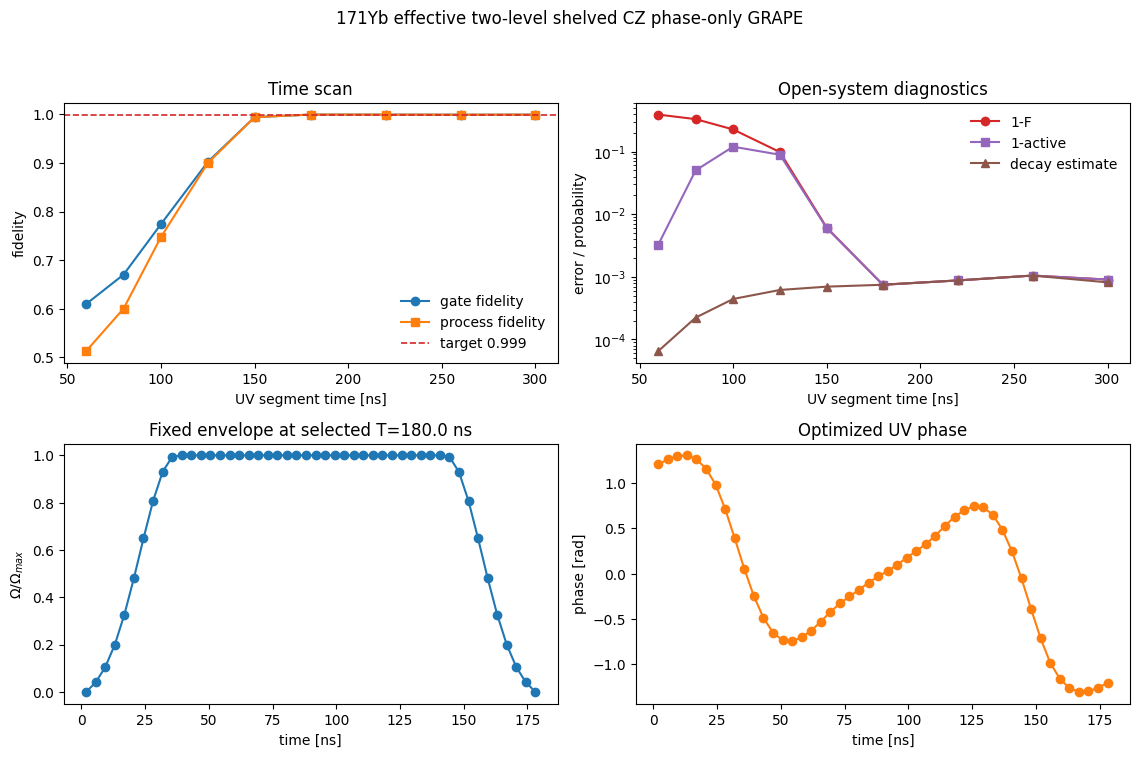

In [6]:
output_dir = ROOT / "artifacts" / "v5" / "effective_two_level_cz_time_scan"
output_dir.mkdir(parents=True, exist_ok=True)
json_path = output_dir / "yb171_effective_two_level_phase_grape_time_scan.json"
png_path = output_dir / "yb171_effective_two_level_phase_grape_time_scan.png"

def result_payload(result: EffectiveShelvedCZResult) -> dict[str, object]:
    return {
        "uv_time_ns": result.uv_time_ns,
        "fidelity": result.fidelity,
        "process_fidelity": result.process_fidelity,
        "active_population": result.active_population,
        "leakage": result.leakage,
        "rydberg_decay_estimate": result.rydberg_decay_estimate,
        "objective": result.objective,
        "success": result.success,
        "num_iter": result.num_iter,
        "num_calls": result.num_calls,
        "wall_time_s": result.wall_time_s,
        "theta0": result.theta0,
        "theta1": result.theta1,
        "gradient_checks": result.gradient_checks,
        "envelope": [float(value) for value in result.envelope],
        "phases": [float(value) for value in result.phases],
        "ctrl_x": [float(value) for value in result.ctrl_x],
        "ctrl_y": [float(value) for value in result.ctrl_y],
    }

payload = {
    "development_stage": "notebook_prototype_for_review",
    "notebook": "notebooks/yb171_effective_two_level_cz_time_optimal_grape.ipynb",
    "paper_context": {
        "reference": "Muniz et al., PRX Quantum 6, 020334 (2025)",
        "doi": "10.1103/PRXQuantum.6.020334",
        "modeling_choice": "ideal shelving/unshelving; optimize only the shelved UV |c>-|r> effective two-level Rydberg segment",
    },
    "model": {
        "basis": list(EffectiveShelvedCZGRAPE.basis_labels),
        "computational_indices": list(EffectiveShelvedCZGRAPE.computational_indices),
        "sector_weights": [1.0, 2.0, 1.0],
        "blockade_shift_hz": 160.0e6,
        "uv_rabi_hz_max": 10.0e6,
        "rydberg_lifetime_s": 65.0e-6,
        "only_noise": "Rydberg decay in the effective no-jump generator",
    },
    "control": {
        "num_tslots": NUM_TSLOTS,
        "gaussian_edge_fraction": 0.20,
        "gaussian_edge_sigma_fraction": 0.08,
        "optimized_variables": "slot phase plus theta0/theta1; amplitude envelope fixed with plateau at Omega_max",
    },
    "scan": {
        "uv_times_ns": UV_TIMES_NS,
        "fidelity_target": FIDELITY_TARGET,
        "shortest_passing_time_ns": None if not passing else best_by_time.uv_time_ns,
        "best_overall_time_ns": best_overall.uv_time_ns,
        "best_overall_fidelity": best_overall.fidelity,
    },
    "results": [result_payload(result) for result in scan_results],
}
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

uv_times = np.array([result.uv_time_ns for result in scan_results], dtype=np.float64)
fidelities = np.array([result.fidelity for result in scan_results], dtype=np.float64)
process = np.array([result.process_fidelity for result in scan_results], dtype=np.float64)
active = np.array([result.active_population for result in scan_results], dtype=np.float64)
decay = np.array([result.rydberg_decay_estimate for result in scan_results], dtype=np.float64)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6))
axes[0, 0].plot(uv_times, fidelities, marker="o", label="gate fidelity")
axes[0, 0].plot(uv_times, process, marker="s", label="process fidelity")
axes[0, 0].axhline(FIDELITY_TARGET, color="tab:red", linestyle="--", linewidth=1.2, label=f"target {FIDELITY_TARGET}")
axes[0, 0].set_xlabel("UV segment time [ns]")
axes[0, 0].set_ylabel("fidelity")
axes[0, 0].set_title("Time scan")
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(uv_times, 1.0 - fidelities, marker="o", color="tab:red", label="1-F")
axes[0, 1].plot(uv_times, 1.0 - active, marker="s", color="tab:purple", label="1-active")
axes[0, 1].plot(uv_times, decay, marker="^", color="tab:brown", label="decay estimate")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("UV segment time [ns]")
axes[0, 1].set_ylabel("error / probability")
axes[0, 1].set_title("Open-system diagnostics")
axes[0, 1].legend(frameon=False)

best = best_by_time
slot_times = (np.arange(best.envelope.size, dtype=np.float64) + 0.5) * best.uv_time_ns / best.envelope.size
axes[1, 0].plot(slot_times, best.envelope, marker="o", color="tab:blue")
axes[1, 0].set_xlabel("time [ns]")
axes[1, 0].set_ylabel(r"$\Omega/\Omega_{max}$")
axes[1, 0].set_ylim(-0.05, 1.05)
axes[1, 0].set_title(f"Fixed envelope at selected T={best.uv_time_ns:.1f} ns")

axes[1, 1].plot(slot_times, best.phases, marker="o", color="tab:orange")
axes[1, 1].set_xlabel("time [ns]")
axes[1, 1].set_ylabel("phase [rad]")
axes[1, 1].set_title("Optimized UV phase")

fig.suptitle("171Yb effective two-level shelved CZ phase-only GRAPE", y=0.99)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
fig.savefig(png_path, dpi=180)
print({"json": str(json_path), "png": str(png_path)})


## Notebook 阶段结论和审查点

本 notebook 完成了第一阶段原型：

- 放弃多个 Rydberg 子能级，只保留 shelving 后的有效 `|c> <-> |r>` UV 模型；
- 对 `|01>/|10>` 用单原子两能级分支，对 `|11>` 用 blockade 对称三能级分支；
- 固定 Gaussian-edge UV 振幅，plateau 恒为 $10\ \mathrm{MHz}$；
- 只优化相位，扫描 UV segment time，寻找达到高 fidelity 阈值的最短时间；
- 唯一开放系统噪声为 Rydberg decay，寿命 $65\ \mu\mathrm{s}$；
- 输出 JSON/PNG artifact 供用户审查。

如果这个 notebook 的模型边界、目标函数和初步时间扫描被批准，下一阶段才生成 Slides 报告。若要提高最短时间结论的可信度，下一轮 notebook 审查后可增加更密的时间网格、多 seed、多 slot 数和更高迭代上限。
